### Convert freqs to radial distances, and vice versa

In [15]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [233]:
import sunpy
sunpy.__version__

'6.0.6'

In [3]:
def freq_to_n(fpe):
    """
    Calculate electron density [cm-3] from plasma frequency in MHz].
    """
    ne = (fpe/(8.98e-3)) ** 2 # for harmonic fpe = 0.5f
    return ne


def n_to_freq(ne):
    """
    Calculate plasma frequency [MHz] from electron density [cm-3].
    """
    fpe = 8.98e-3 * np.sqrt(ne)
    return fpe


def newkirk(r, fold=1):
    """
    Newkirk electron-density model.
    fold: is a multiplicative factor to change the density scaling.
    """
    model = fold * 4.2e4 * 10 ** (4.32 / r)
    return model


def height_to_freq(r):
    """
    Convert radial height (in Rsun) to plasma frequency (MHz)
    using the Newkirk density model.
    """
    ne = newkirk(r)
    fpe = n_to_freq(ne)
    return fpe


def invert_newkirk(ne):
    """
    Invert the Newkirk electron-density model to find the radial distance
    for a given electron density.
    """

    def equation(r):
        # Define the equation for which we need to find the root.
        # It returns the difference between the model's density and the given density.
        return newkirk(r) - ne

    # Initial guess for the radial distance can be set to a reasonable value.
    r_guess = 1.0

    # Use fsolve to find the root of the equation, which is the radial distance r
    # that makes the equation zero.
    r_solution, = fsolve(equation, r_guess)
    return r_solution

In [6]:
df = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3MF.csv')
df.columns

Index(['Unnamed: 0', 'Time', '1 Leblanc', '2 Leblanc', '3 Leblanc',
       '4 Leblanc', '1 Mann', '2 Mann', '3 Mann', '4 Mann', '1 Saito',
       '2 Saito', '3 Saito', '4 Saito', '1 Allen', '2 Allen', '3 Allen',
       '4 Allen', '1 Newkirk', '2 Newkirk', '3 Newkirk', '4 Newkirk'],
      dtype='object')

In [12]:
time = df['Time'].values
r_list = df['1 Newkirk'].values
r_list

array([1.33738667, 1.33653199, 1.33842695, 1.34121251, 1.3431681 ,
       1.35022247, 1.35563948, 1.36017311, 1.36992595, 1.3775402 ,
       1.37987628, 1.38083596, 1.38088644, 1.38059093, 1.37990247,
       1.38106003, 1.38380136, 1.38504091, 1.38516403, 1.38620653,
       1.38610799, 1.38794402, 1.39081746, 1.39059469, 1.39101833,
       1.39259378, 1.39336688, 1.39374767, 1.39553457, 1.39646915])

In [13]:
freqs = height_to_freq(r_list)
freqs

array([75.85620363, 76.03681497, 75.63726058, 75.05575849, 74.65162028,
       73.22128613, 72.15143316, 71.27449452, 69.44301049, 68.06334685,
       67.64858476, 67.47933364, 67.47045001, 67.5224851 , 67.64395663,
       67.43991121, 66.96049452, 66.7454567 , 66.72415568, 66.54422158,
       66.56119691, 66.24600784, 65.75737529, 65.79505703, 65.72342768,
       65.45811446, 65.32853185, 65.26485193, 64.96732034, 64.81255002])

In [106]:
dflf = pd.read_csv('/home/mnedal/data/ccuddy/updated/hs_3LF.csv')
dfmf = pd.read_csv('/home/mnedal/data/ccuddy/updated/hs_3MF.csv')
dfuf = pd.read_csv('/home/mnedal/data/ccuddy/updated/hs_3HF.csv')

freqslf = height_to_freq(dflf['1 Newkirk'].values)
freqsmf = height_to_freq(dfmf['1 Newkirk'].values)
freqsuf = height_to_freq(dfuf['1 Newkirk'].values)

dflh = pd.read_csv('/home/mnedal/data/ccuddy/updated/hs_3LH.csv')
dfmh = pd.read_csv('/home/mnedal/data/ccuddy/updated/hs_3MH.csv')
dfuh = pd.read_csv('/home/mnedal/data/ccuddy/updated/hs_3HH.csv')

freqslh = height_to_freq(dflh['1 Newkirk'].values)
freqsmh = height_to_freq(dfmh['1 Newkirk'].values)
freqsuh = height_to_freq(dfuh['1 Newkirk'].values)

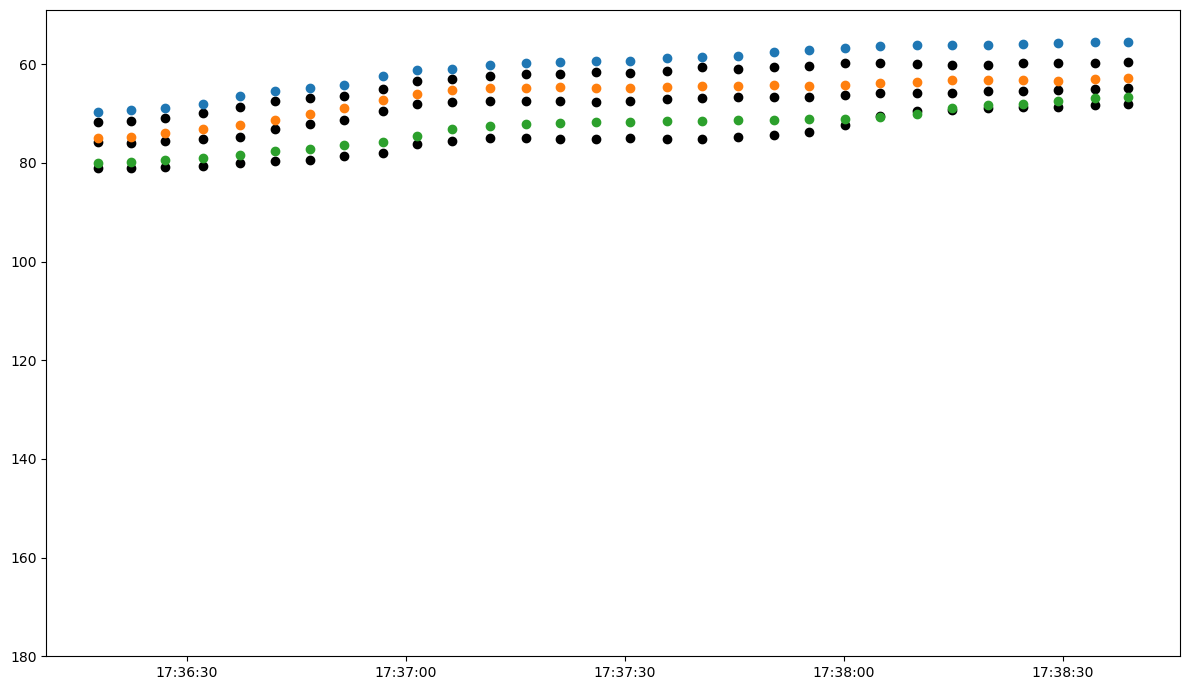

In [31]:
fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)

ax.scatter(time, freqslf, c='k')
ax.scatter(time, freqsmf, c='k')
ax.scatter(time, freqsuf, c='k')

ax.scatter(time, freqslh)
ax.scatter(time, freqsmh)
ax.scatter(time, freqsuh)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
# ax.set_ylim(ax.get_ylim()[::-1])
ax.set_ylim(180, 49)
fig.tight_layout()
plt.show()

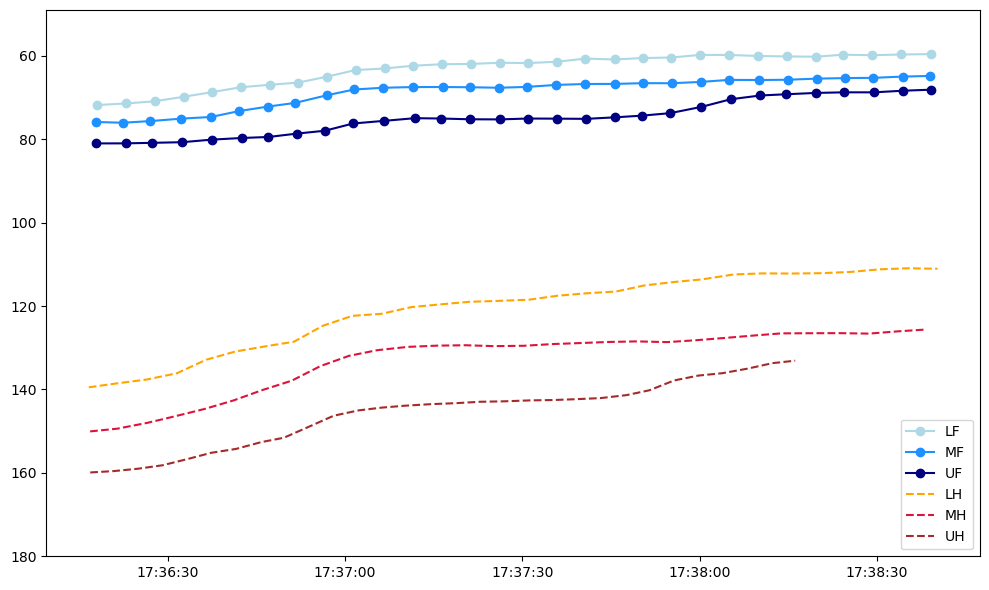

In [177]:
dflf = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst3LF_stats.csv')
dfmf = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst3MF_stats.csv')
dfuf = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst3UF_stats.csv')

freqslf = dflf['f_means'].values
freqsmf = dfmf['f_means'].values
freqsuf = dfuf['f_means'].values

timelf = dflf['t_means'].values
timemf = dfmf['t_means'].values
timeuf = dfuf['t_means'].values

dflh = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst3LH_stats.csv')
dfmh = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst3MH_stats.csv')
dfuh = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst3UH_stats.csv')

freqslh = dflh['f_means'].values
freqsmh = dfmh['f_means'].values
freqsuh = dfuh['f_means'].values

timelh = dflh['t_means'].values
timemh = dfmh['t_means'].values
timeuh = dfuh['t_means'].values



fig = plt.figure(figsize=[10,6])
ax = fig.add_subplot(111)

ax.plot(timelf, freqslf, '-o', c='lightblue', label='LF')
ax.plot(timemf, freqsmf, '-o', c='dodgerblue', label='MF')
ax.plot(timeuf, freqsuf, '-o', c='navy', label='UF')

ax.plot(timelh, freqslh, '--', c='orange', label='LH')
ax.plot(timemh, freqsmh, '--', c='crimson', label='MH')
ax.plot(timeuh, freqsuh, '--', c='brown', label='UH')

ax.legend()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.set_ylim(180, 49)
fig.tight_layout()
plt.show()

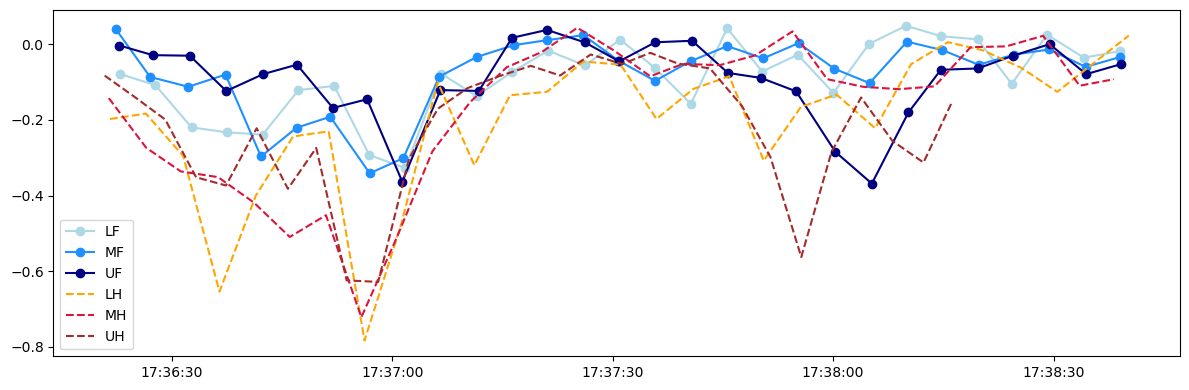

In [174]:
# calc drift rates
timelf_ = mdates.num2date(timelf)
timemf_ = mdates.num2date(timemf)
timeuf_ = mdates.num2date(timeuf)

dtimelf = [(b - a).total_seconds() for a, b in zip(timelf_[:-1], timelf_[1:])]
dtimemf = [(b - a).total_seconds() for a, b in zip(timemf_[:-1], timemf_[1:])]
dtimeuf = [(b - a).total_seconds() for a, b in zip(timeuf_[:-1], timeuf_[1:])]

dfdt_lf = np.diff(freqslf)/dtimelf
dfdt_mf = np.diff(freqsmf)/dtimemf
dfdt_uf = np.diff(freqsuf)/dtimeuf

timelh_ = mdates.num2date(timelh)
timemh_ = mdates.num2date(timemh)
timeuh_ = mdates.num2date(timeuh)

dtimelh = [(b - a).total_seconds() for a, b in zip(timelh_[:-1], timelh_[1:])]
dtimemh = [(b - a).total_seconds() for a, b in zip(timemh_[:-1], timemh_[1:])]
dtimeuh = [(b - a).total_seconds() for a, b in zip(timeuh_[:-1], timeuh_[1:])]

dfdt_lh = np.diff(freqslh)/dtimelh
dfdt_mh = np.diff(freqsmh)/dtimemh
dfdt_uh = np.diff(freqsuh)/dtimeuh


fig = plt.figure(figsize=[12,4])
ax = fig.add_subplot(111)

ax.plot(timelf_[1:], dfdt_lf, '-o', c='lightblue', label='LF')
ax.plot(timemf_[1:], dfdt_mf, '-o', c='dodgerblue', label='MF')
ax.plot(timeuf_[1:], dfdt_uf, '-o', c='navy', label='UF')

ax.plot(timelh_[1:], dfdt_lh, '--', c='orange', label='LH')
ax.plot(timemh_[1:], dfdt_mh, '--', c='crimson', label='MH')
ax.plot(timeuh_[1:], dfdt_uh, '--', c='brown', label='UH')

ax.legend()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
fig.tight_layout()
plt.show()

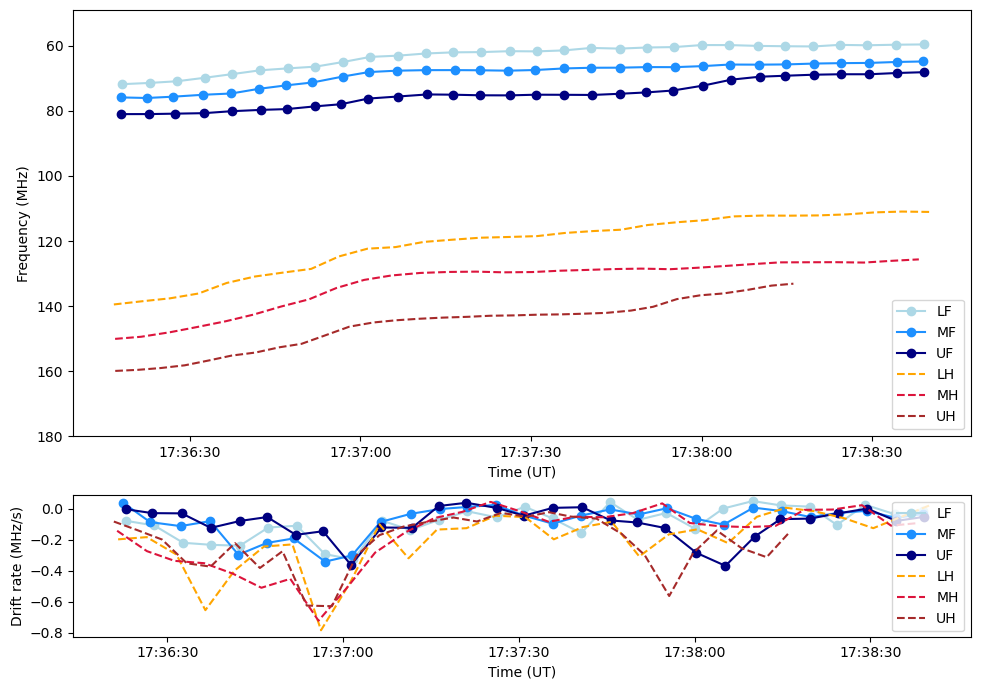

In [184]:
# using point-to-point differencing
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=[10, 7],
    gridspec_kw={'height_ratios': [3, 1]}
)

ax = axes[0]
ax.plot(timelf, freqslf, '-o', c='lightblue', label='LF')
ax.plot(timemf, freqsmf, '-o', c='dodgerblue', label='MF')
ax.plot(timeuf, freqsuf, '-o', c='navy', label='UF')
ax.plot(timelh, freqslh, '--', c='orange', label='LH')
ax.plot(timemh, freqsmh, '--', c='crimson', label='MH')
ax.plot(timeuh, freqsuh, '--', c='brown', label='UH')
ax.set_ylabel('Frequency (MHz)')
ax.set_xlabel('Time (UT)')
ax.legend()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.set_ylim(180, 49)

ax = axes[1]
ax.plot(timelf_[1:], dfdt_lf, '-o', c='lightblue', label='LF')
ax.plot(timemf_[1:], dfdt_mf, '-o', c='dodgerblue', label='MF')
ax.plot(timeuf_[1:], dfdt_uf, '-o', c='navy', label='UF')
ax.plot(timelh_[1:], dfdt_lh, '--', c='orange', label='LH')
ax.plot(timemh_[1:], dfdt_mh, '--', c='crimson', label='MH')
ax.plot(timeuh_[1:], dfdt_uh, '--', c='brown', label='UH')
ax.set_ylabel('Drift rate (MHz/s)')
ax.set_xlabel('Time (UT)')
ax.legend()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

fig.tight_layout()
plt.show()

In [185]:
# using savitsky-golay filter
from scipy.signal import savgol_filter

# window_length = min(len(y_va) if len(y_va)%2==1 else len(y_va)-1, 11)
# polyorder = 2 if window_length > 2 else 1
# y_va_smooth = savgol_filter(y_va, window_length=window_length, polyorder=polyorder)
# y_err = np.abs(y_va - y_va_smooth) # Residual-based error bars
# 
# ax.errorbar(dist_Rs, y_va, yerr=y_err, fmt='o', ms=3, color='crimson') # Original with error bars from residuals
# ax.plot(dist_Rs, y_va_smooth, '--', lw=2, color='gray') # Smoothed curve

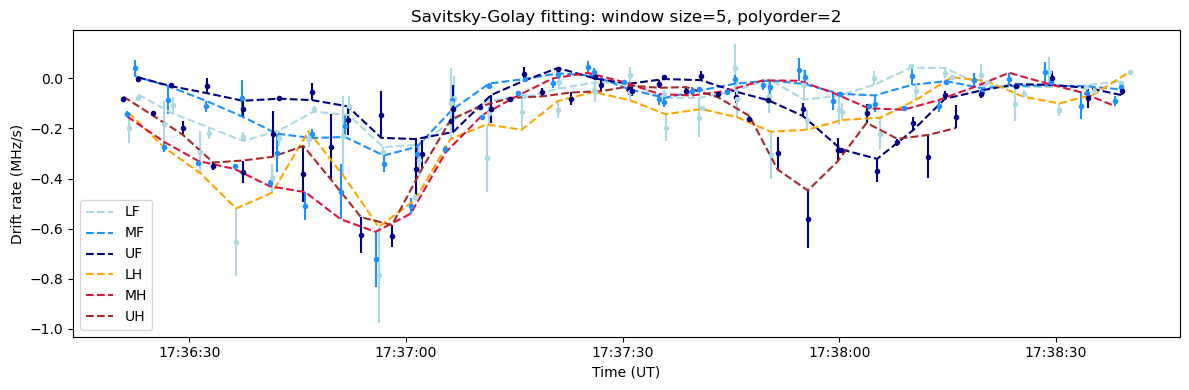

In [208]:
windowsize = 5
polorder = 2

ysmooth_lf = savgol_filter(dfdt_lf, window_length=windowsize, polyorder=polorder)
ysmooth_mf = savgol_filter(dfdt_mf, window_length=windowsize, polyorder=polorder)
ysmooth_uf = savgol_filter(dfdt_uf, window_length=windowsize, polyorder=polorder)

yerr_lf = np.abs(dfdt_lf - ysmooth_lf)
yerr_mf = np.abs(dfdt_mf - ysmooth_mf)
yerr_uf = np.abs(dfdt_uf - ysmooth_uf)

ysmooth_lh = savgol_filter(dfdt_lh, window_length=windowsize, polyorder=polorder)
ysmooth_mh = savgol_filter(dfdt_mh, window_length=windowsize, polyorder=polorder)
ysmooth_uh = savgol_filter(dfdt_uh, window_length=windowsize, polyorder=polorder)

yerr_lh = np.abs(dfdt_lh - ysmooth_lh)
yerr_mh = np.abs(dfdt_mh - ysmooth_mh)
yerr_uh = np.abs(dfdt_uh - ysmooth_uh)



fig = plt.figure(figsize=[12,4])
ax = fig.add_subplot(111)

ax.errorbar(timelf[1:], dfdt_lf, yerr=yerr_lf, fmt='o', ms=3, color='lightblue')
ax.errorbar(timemf[1:], dfdt_mf, yerr=yerr_mf, fmt='o', ms=3, color='dodgerblue')
ax.errorbar(timeuf[1:], dfdt_uf, yerr=yerr_uf, fmt='o', ms=3, color='navy')

ax.plot(timelf[1:], ysmooth_lf, '--', c='lightblue', label='LF')
ax.plot(timemf[1:], ysmooth_mf, '--', c='dodgerblue', label='MF')
ax.plot(timeuf[1:], ysmooth_uf, '--', c='navy', label='UF')

ax.errorbar(timelh[1:], dfdt_lh, yerr=yerr_lh, fmt='o', ms=3, color='lightblue')
ax.errorbar(timemh[1:], dfdt_mh, yerr=yerr_mh, fmt='o', ms=3, color='dodgerblue')
ax.errorbar(timeuh[1:], dfdt_uh, yerr=yerr_uh, fmt='o', ms=3, color='navy')

ax.plot(timelh[1:], ysmooth_lh, '--', c='orange', label='LH')
ax.plot(timemh[1:], ysmooth_mh, '--', c='crimson', label='MH')
ax.plot(timeuh[1:], ysmooth_uh, '--', c='brown', label='UH')

ax.set_title(f'Savitsky-Golay fitting: window size={windowsize}, polyorder={polorder}')
ax.set_ylabel('Drift rate (MHz/s)')
ax.set_xlabel('Time (UT)')
ax.legend()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
fig.tight_layout()
plt.show()

In [221]:
target_str = '2024-05-14 17:37:00'

import datetime

target_dt = datetime.datetime.strptime(
    target_str,
    '%Y-%m-%d %H:%M:%S'
).replace(tzinfo=datetime.timezone.utc)

try:
    idx = timelh_.index(target_dt)
except:
    idx = min(
    range(len(timelh_)),
    key=lambda i: abs(timelh_[i] - target_dt)
)

print(idx, timelh_[idx])

9 2024-05-14 17:37:01.228856+00:00


In [229]:
print(f'LF: {np.mean(dfdt_lf[idx:]):.2f} MHz/s')
print(f'MF: {np.mean(dfdt_mf[idx:]):.2f} MHz/s')
print(f'UF: {np.mean(dfdt_uf[idx:]):.2f} MHz/s')
print('\n')
print(f'LH: {np.mean(dfdt_lh[idx:]):.2f} MHz/s')
print(f'MH: {np.mean(dfdt_mh[idx:]):.2f} MHz/s')
print(f'UH: {np.mean(dfdt_uh[idx:]):.2f} MHz/s')

LF: -0.04 MHz/s
MF: -0.03 MHz/s
UF: -0.08 MHz/s


LH: -0.11 MHz/s
MH: -0.06 MHz/s
UH: -0.19 MHz/s


In [231]:
timelh_[idx:][0], timelh_[idx:][-1]

(datetime.datetime(2024, 5, 14, 17, 37, 1, 228856, tzinfo=datetime.timezone.utc),
 datetime.datetime(2024, 5, 14, 17, 38, 40, 231893, tzinfo=datetime.timezone.utc))